In [1]:
import jax.random as jr
import jax.numpy as jnp
import jax
from jax.scipy.special import gammaln

import sys
import os
import json

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

from optimization import optimization_utils

import model_definition.two_phase_integrative_ude_constant_transmission as two_phase_integrative_ude
import data.data_utils_integrative_model as data_utils_integrative_model
import model_definition.model_utils as model_utils

import equinox as eqx
import pandas as pd
import argparse
import optuna
import pathlib

import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

/home/iru-mls/Documents/repositories/ww_bonn_jax/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
town = "Bonn_constant_transmission"
objective = "cases_and_conc"
cutoff_value = 0.05 # cutoff value for ensemble member selection (fraction of best models)

phase_cut_date = "2023-03-15"

In [3]:
path = "/home/iru-mls/marvin/ww_bonn_jax"

In [4]:
base_config = {
        # General settings
        "seed": 0,  # random seed

        # data selection settings
        "data_kwargs": {
            "town": "Bonn",
            "sampling_area": "North_South",
            "project": "both", # one of ESI_CorA, AMELAG
            "max_precipitation_subsetting": None, # one of None, dry, light_rain
            "substance_normalization": "flow", # one of None, PMMoV, flow
            "gene_target": "N1", # one of N1, N2
            "log_scale": True, # this only considers WW measurements, not case counts
        },
        
        "E0": 862.857, 
        "I0": 1294.286,
        "R0": 162092.04, # 92% of pop, based on https://www.rki.de/DE/Themen/Infektionskrankheiten/Infektionskrankheiten-A-Z/C/COVID-19-Pandemie/AK-Studien/Ergebnisse.html
        "dt": 0.2,
        "underreporting_model": "monotone_increasing",
}

base_config["phase_cut_date"] = phase_cut_date
base_config["n_days_pred_conc"] = 0
model_path = pathlib.Path(f"{path}/Bonn_constant_transmission/optuna_best_{base_config['phase_cut_date']}_{objective}")

def build_config_from_saved(base_config, hparams: dict) -> dict:
    """Merge base config from integrative_ude_optuna.py with saved trial params."""
    import copy

    base = copy.deepcopy(base_config)
    base.update(hparams)
    # Keep solver kwargs consistent
    if "solver_kwargs" not in base:
        base["solver_kwargs"] = {
            "rtol": hparams.get("rtol"),
            "atol": hparams.get("atol"),
        }
    else:
        base["solver_kwargs"]["rtol"] = hparams.get(
            "rtol", base["solver_kwargs"].get("rtol")
        )
        base["solver_kwargs"]["atol"] = hparams.get(
            "atol", base["solver_kwargs"].get("atol")
        )
    return base

with open(f"{model_path}/hparams.json") as f:
    hparams = json.load(f)

# Merge with base config from your Optuna script
config = build_config_from_saved(base_config, hparams)

# Generate dataset
data = optimization_utils.two_phase_integrative_model_load_data(config)

model = two_phase_integrative_ude.IntegrativeModel(
    width_size=config["width_size"],
    depth=config["depth"],
    activation=model_utils.activation_fct_mapper[config["activation"]],
    underreporting_model=config["underreporting_model"],
    n_freqs=config["n_freqs"],
    t_scale=data["t_scale"],
    population_size=data["population_size"],
    E0_init=config["E0"],
    I0_init=config["I0"],
    R0_init=config["R0"],
    solver=model_utils.solver_mapper[config["solver"]],
    solver_kwargs=config["solver_kwargs"],
    k1_init=config["k1_init"],
    k2_init=config["k2_init"],
    k3_init=config["k3_init"],
    T_peak_init=config["T_peak_init"],
    T_max=config["T_max"],
    dt = config["dt"],
    key=jr.key(config["seed"]),
    init_par_vmr=config.get("init_par_vmr", 1.0),
    init_sigma_C=config.get("init_sigma_C", 1.0),
    reporting_delay=config.get("reporting_delay", 3),
    initial_transmission=0.3) # days, delay between infection and reporting

model = eqx.tree_deserialise_leaves(f"{model_path}/model.eqx", model)



In [5]:
model.UDE.rhs.transmission_rate

0.2992000186079264

In [6]:
t_all = data["t_all"]
t_phase_1 = data["t_phase_1"]
I_dates_train, I_train = data["I_dates_train"], data["I_train"]
I_dates_val, I_val = data["I_dates_val"], data["I_val"]
obs_dates_phase_2, obs_I_phase_2 = data["obs_dates_phase_2"], data["I_test"]
dates_all = data["dates_all"]
conc_dates_train, conc_train = data["conc_dates_train"], data["conc_train"]
conc_dates_val, conc_val = data["conc_dates_val"], data["conc_val"]
t_all_idx = data["t_all_idx"]

In [7]:
import jax.nn as jnn
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def set_fontsize(base_fontsize=15):
    fontsize = base_fontsize
    plt.rcParams.update({
        'font.size': fontsize,
        'axes.titlesize': fontsize * 1,
        'axes.labelsize': fontsize,
        'xtick.labelsize': fontsize * 0.8,
        'ytick.labelsize': fontsize * 0.8,
        'legend.fontsize': fontsize * 0.8,
        'font.family': "Arial"
    })

plt.style.use('default')

set_fontsize()

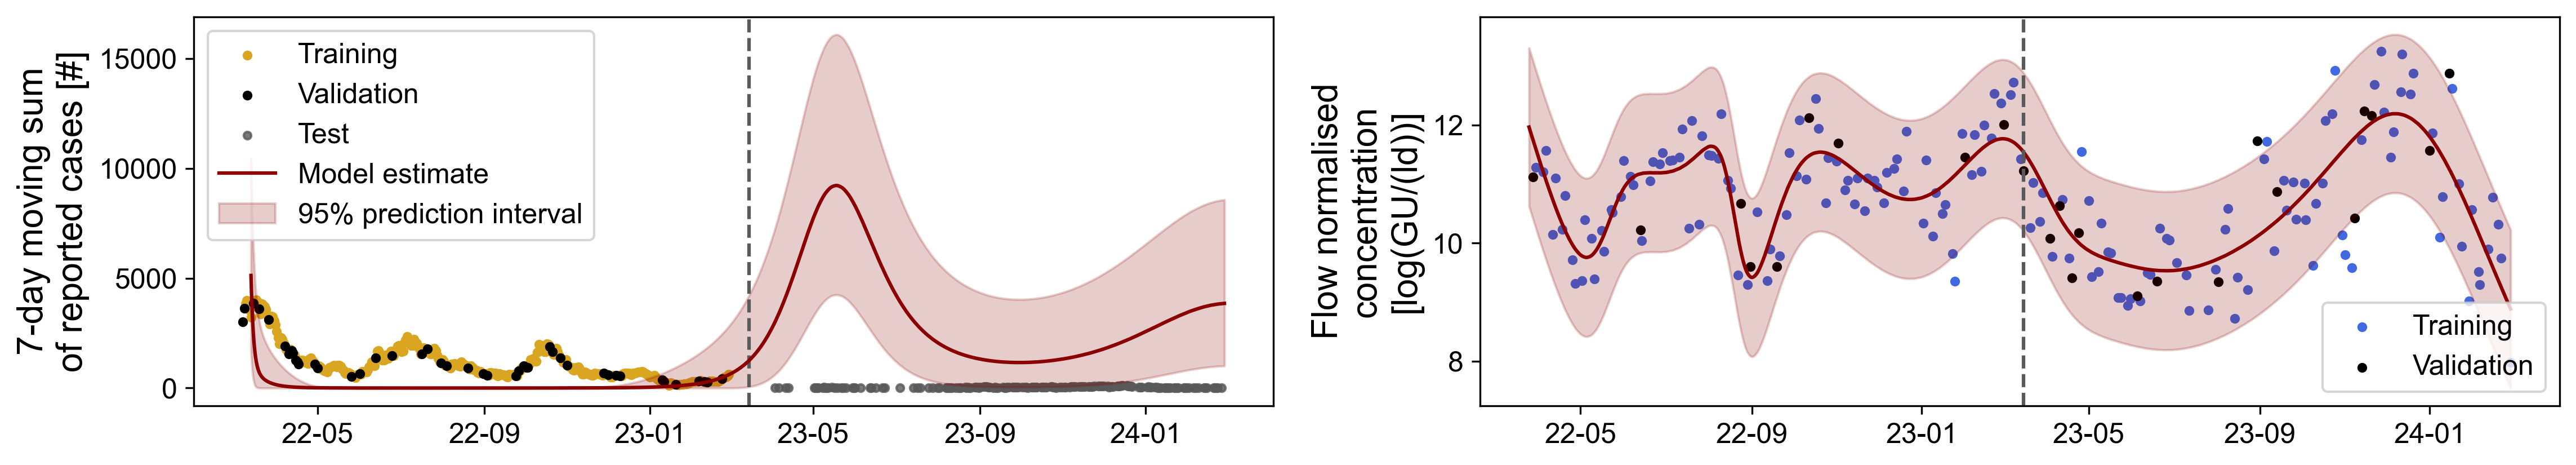

In [9]:
from scipy.stats import nbinom
pred_conc, I_new_7d_pred = model(t_all, t_phase_1)

vmr = 1 + jnn.softplus(model.par_vmr)
sigma_C = jnp.exp(model.log_sigma_C)

fig, axs = plt.subplots(1,2, figsize=(15.5, 3), dpi=300)
axs[0].scatter(I_dates_train, I_train, label="Training", color="goldenrod", s=10)
axs[0].scatter(I_dates_val, I_val, label="Validation", color="black", s=10)
axs[0].scatter(obs_dates_phase_2, obs_I_phase_2, label="Test", color="#595959", s=10, alpha=0.8)

axs[0].axvline(pd.to_datetime(phase_cut_date), color="#595959", linestyle='--')

axs[0].plot(dates_all[1:], I_new_7d_pred, label="Model estimate", color="#8B0000")

# Error band: alpha = 0.05
alpha = 0.05
eps = 1e-12
vmr = jnp.maximum(vmr, 1.0 + 1e-6)   # keep away from exactly 1 to avoid r→∞
p = 1.0 / vmr
r = I_new_7d_pred / (vmr - 1.0)
# Clip to numerically safe range
p = jnp.clip(p, eps, 1.0 - eps)
r = jnp.clip(r, eps, 1e12)
q_lo = nbinom.ppf(alpha/2.0, r, p)
q_hi = nbinom.ppf(1.0 - alpha/2.0, r, p)
axs[0].fill_between(dates_all[1:], 
                q_lo, 
                q_hi, 
                color="#8B0000", alpha=0.2, label="95% prediction interval")

axs[0].legend()

axs[0].set_ylabel("7-day moving sum\nof reported cases [#]")

axs[1].scatter(conc_dates_train, conc_train, label="Training", color="royalblue", s=10)
axs[1].scatter(conc_dates_val, conc_val, label="Validation", color="black", s=10)

axs[1].plot(dates_all[t_all_idx*model.dt >= int(model.T_max)], pred_conc, color="#8B0000", label=None)

# Error band: ±1 std
axs[1].fill_between(dates_all[t_all_idx*model.dt >= int(model.T_max)],
                    pred_conc - 1.96*sigma_C,
                    pred_conc + 1.96*sigma_C,
                    color="#8B0000", alpha=0.2, label=None)

axs[1].legend()
axs[1].axvline(pd.to_datetime(phase_cut_date), color="#595959", linestyle='--', label=None)

axs[1].set_ylabel(
    "Flow normalised\nconcentration\n[log(GU/(ld))]")


axs[0].xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 5, 9)))
axs[0].xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
axs[1].xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 5, 9)))
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
plt.tight_layout()

plt.savefig(f"Bonn_constant_transmission_results.png", dpi=300)